In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("../data/processed/02_cleaned.csv")

df.head()

,timestamp,temperature,humidity,co2,yield_kg
0,2026-06-01 08:00:00,25.7,79.0,929.0,12.34
1,2026-06-01 09:00:00,24.8,83.0,945.0,12.55
2,2026-06-01 10:00:00,26.0,84.0,987.0,13.60
3,2026-06-01 11:00:00,27.3,82.0,984.0,13.49
4,2026-06-01 12:00:00,24.6,84.0,790.0,12.98


In [5]:
df.shape


(100, 5)

In [6]:
df.columns


Index(['timestamp', 'temperature', 'humidity', 'co2', 'yield_kg'], dtype='str')

In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'])


In [8]:
print("Start Date:", df['timestamp'].min())
print("End Date:", df['timestamp'].max())

Start Date: 2026-06-01 08:00:00
End Date: 2026-06-05 11:00:00


In [9]:
df.describe()


,timestamp,temperature,humidity,co2,yield_kg
count,100,100.000000,100.000000,100.000000,100.00000
mean,2026-06-03 09:30:00,24.841000,85.100000,905.210000,13.08560
min,2026-06-01 08:00:00,21.100000,77.000000,641.000000,11.30000
25%,2026-06-02 08:45:00,24.100000,82.000000,847.750000,12.54750
50%,2026-06-03 09:30:00,24.800000,85.000000,908.000000,13.04000
75%,2026-06-04 10:15:00,25.625000,87.000000,956.500000,13.55000
max,2026-06-05 11:00:00,27.800000,96.000000,1208.000000,14.75000
std,NaN,1.361008,3.865151,86.719832,0.70723


In [10]:
print("Temperature < 0:", (df['temperature'] < 0).sum())
print("Humidity < 0:", (df['humidity'] < 0).sum())
print("Humidity > 100:", (df['humidity'] > 100).sum())
print("CO2 < 0:", (df['co2'] < 0).sum())
print("Yield < 0:", (df['yield_kg'] < 0).sum())

Temperature < 0: 0
Humidity < 0: 0
Humidity > 100: 0
CO2 < 0: 0
Yield < 0: 0


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully!


In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/02_cleaned.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'])

In [4]:
df.head()

,timestamp,temperature,humidity,co2,yield_kg
0,2026-06-01 08:00:00,25.7,79.0,929.0,12.34
1,2026-06-01 09:00:00,24.8,83.0,945.0,12.55
2,2026-06-01 10:00:00,26.0,84.0,987.0,13.60
3,2026-06-01 11:00:00,27.3,82.0,984.0,13.49
4,2026-06-01 12:00:00,24.6,84.0,790.0,12.98


In [5]:
correlation_matrix = df[['temperature', 'humidity', 'co2', 'yield_kg']].corr()

correlation_matrix

,temperature,humidity,co2,yield_kg
temperature,1.000000,-0.129630,0.191871,-0.168440
humidity,-0.129630,1.000000,-0.044152,-0.022378
co2,0.191871,-0.044152,1.000000,0.000692
yield_kg,-0.168440,-0.022378,0.000692,1.000000


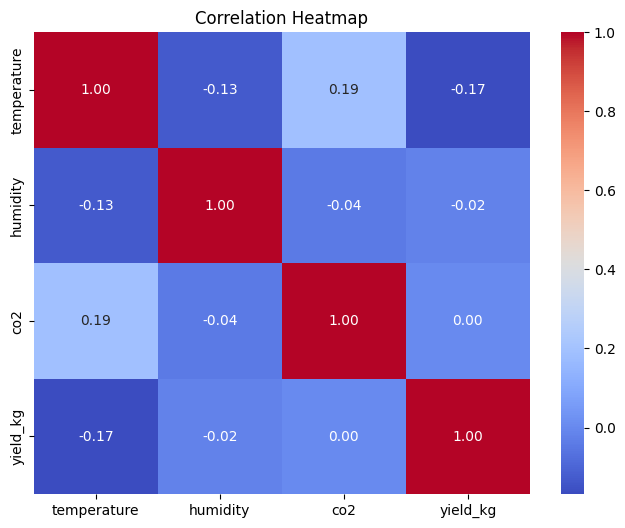

In [6]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

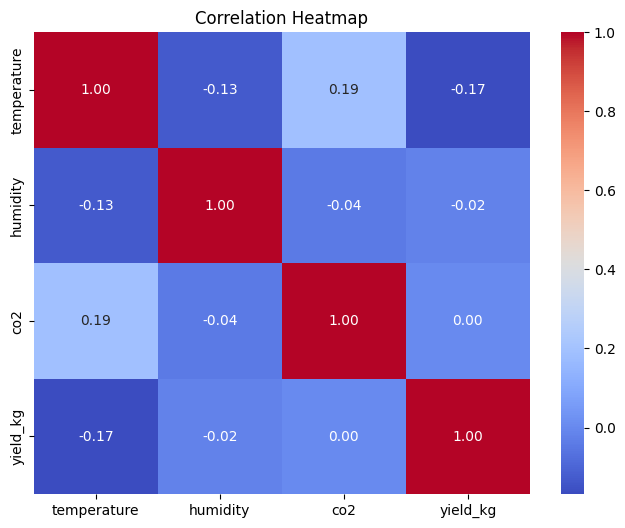

In [7]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("../reports/figures/correlation_heatmap.png")

plt.show()

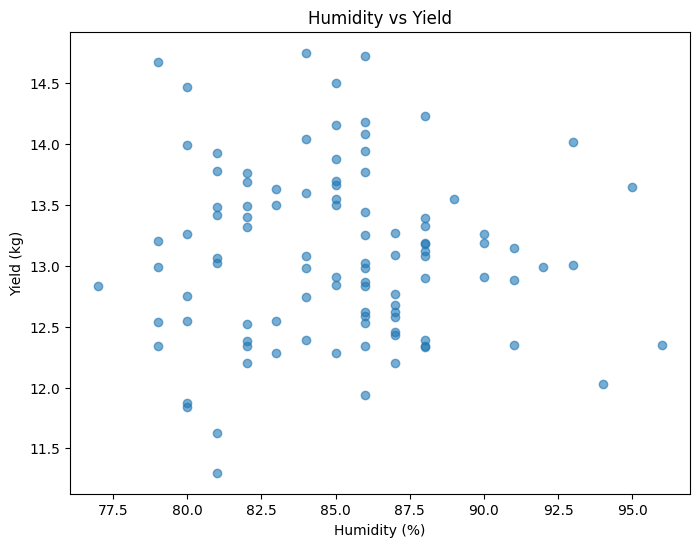

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['humidity'],
    df['yield_kg'],
    alpha=0.6
)

plt.xlabel("Humidity (%)")
plt.ylabel("Yield (kg)")
plt.title("Humidity vs Yield")

plt.savefig("../reports/figures/humidity_vs_yield.png")

plt.show()

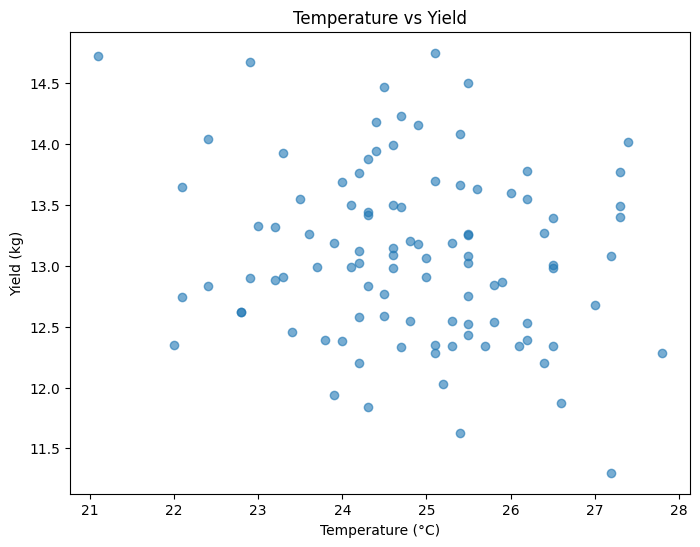

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['temperature'],
    df['yield_kg'],
    alpha=0.6
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Yield (kg)")
plt.title("Temperature vs Yield")

plt.savefig("../reports/figures/temperature_vs_yield.png")

plt.show()

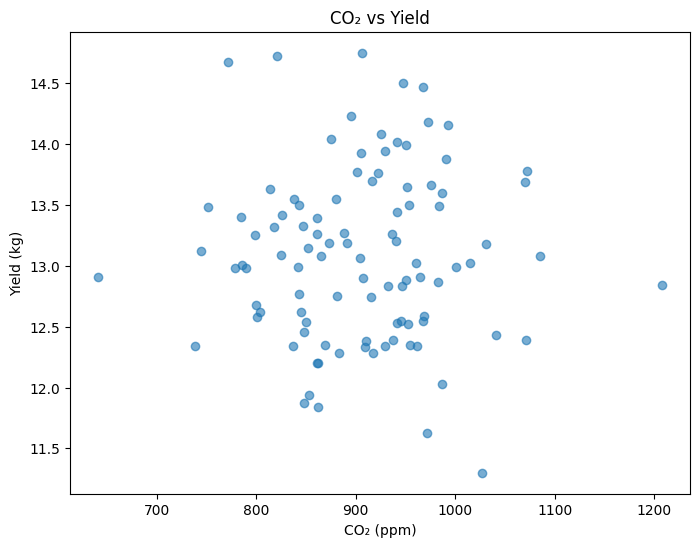

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['co2'],
    df['yield_kg'],
    alpha=0.6
)

plt.xlabel("CO₂ (ppm)")
plt.ylabel("Yield (kg)")
plt.title("CO₂ vs Yield")

plt.savefig("../reports/figures/co2_vs_yield.png")

plt.show()